# Домашнее задание №10. Памперсы или пиво? Рекомендательная система на данных Amazon

**Датасет:** [Amazon Product Data (2018), 5-core subset](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/) — категория **Digital Music**
(`Digital_Music_5.json.gz`, ~170 тыс. отзывов).
## План работы

| # | Этап | Что делаем |
|---|---|---|
| 1 | Загрузка данных | читаем `.json.gz` построчно, оставляем `user / item / rating / timestamp` |
| 2 | Базовый EDA | распределение рейтингов, активность пользователей, популярность товаров, long tail, динамика по годам, разреженность |
| 3 | Предобработка | дедупликация пар `(user, item)`, восстановление 5-core после дедупа |
| 4 | Train/test split | **leave-one-out** по времени: последнее взаимодействие — в тест, предпоследнее — в валидацию |
| 5 | Модели | Random → Top-Popular → ItemKNN (косинус) → ALS (`implicit`) → BPR (`implicit`) |
| 6 | Оценка качества | HR@10, MRR@10, NDCG@10, Coverage@10 |
| 7 | Выводы | сравнение моделей, точность vs. разнообразие, что делать дальше |


## 1. Импорты и настройки

In [3]:
import gzip
import json
import time
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize

import implicit

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
TOP_K = 10          # длина списка рекомендаций во всех метриках
rng = np.random.default_rng(RANDOM_STATE)

print("numpy", np.__version__, "| pandas", pd.__version__, "| implicit", implicit.__version__)

numpy 2.5.0 | pandas 3.0.3 | implicit 0.7.3


## 2. Загрузка данных

In [4]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

CATEGORY = "Digital_Music"
DATA_FILE = DATA_DIR / f"{CATEGORY}_5.json.gz"
DATA_URL = (
    "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/"
    f"categoryFilesSmall/{CATEGORY}_5.json.gz"
)

if not DATA_FILE.exists():
    print(f"Скачиваем {DATA_URL} ...")
    urlretrieve(DATA_URL, DATA_FILE)

print(f"{DATA_FILE} — {DATA_FILE.stat().st_size / 1024**2:.1f} МБ")

data\Digital_Music_5.json.gz — 18.6 МБ


In [7]:
USER_COL, ITEM_COL, RATING_COL, TIME_COL = "user_id", "item_id", "rating", "timestamp"

rows = []
with gzip.open(DATA_FILE, "rt", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        rows.append((r["reviewerID"], r["asin"], r["overall"], r["unixReviewTime"]))

data = pd.DataFrame(rows, columns=[USER_COL, ITEM_COL, RATING_COL, TIME_COL])
data[RATING_COL] = data[RATING_COL].astype(np.float32)
data["date"] = pd.to_datetime(data[TIME_COL], unit="s")

print(data.shape)
data.head()

(169781, 5)


,user_id,item_id,rating,timestamp,date
0,A2TYZ821XXK2YZ,3426958910,5.0,1370217600,2013-06-03
1,A3OFSREZADFUDY,3426958910,5.0,1412985600,2014-10-11
2,A2VAMODP8M77NG,3426958910,5.0,1392076800,2014-02-11
3,AAKSLZ9IDTEH0,3426958910,4.0,1386374400,2013-12-07
4,A3OH43OZJLKI09,5557706259,5.0,1465689600,2016-06-12


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 169781 entries, 0 to 169780
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   user_id    169781 non-null  str          
 1   item_id    169781 non-null  str          
 2   rating     169781 non-null  float32      
 3   timestamp  169781 non-null  int64        
 4   date       169781 non-null  datetime64[s]
dtypes: datetime64[s](1), float32(1), int64(1), str(2)
memory usage: 9.7 MB


## 3. Базовый EDA

### 3.1 Общие цифры

In [9]:
n_inter = len(data)
n_users = data[USER_COL].nunique()
n_items = data[ITEM_COL].nunique()

summary = pd.Series(
    {
        "Взаимодействий (отзывов)": n_inter,
        "Уникальных пользователей": n_users,
        "Уникальных товаров": n_items,
        "Среднее число отзывов на пользователя": round(n_inter / n_users, 2),
        "Среднее число отзывов на товар": round(n_inter / n_items, 2),
        "Разреженность матрицы, %": round(100 * (1 - n_inter / (n_users * n_items)), 4),
        "Период наблюдений": f"{data['date'].min():%Y-%m-%d} — {data['date'].max():%Y-%m-%d}",
        "Дубликатов (user, item)": int(data.duplicated([USER_COL, ITEM_COL]).sum()),
        "Пропусков в данных": int(data.isna().sum().sum()),
    }
)
summary.to_frame("значение")

,значение
Взаимодействий (отзывов),169781
Уникальных пользователей,16566
Уникальных товаров,11797
Среднее число отзывов на пользователя,10.25
Среднее число отзывов на товар,14.39
"Разреженность матрицы, %",99.9131
Период наблюдений,1998-07-09 — 2018-09-26
"Дубликатов (user, item)",24489
Пропусков в данных,0


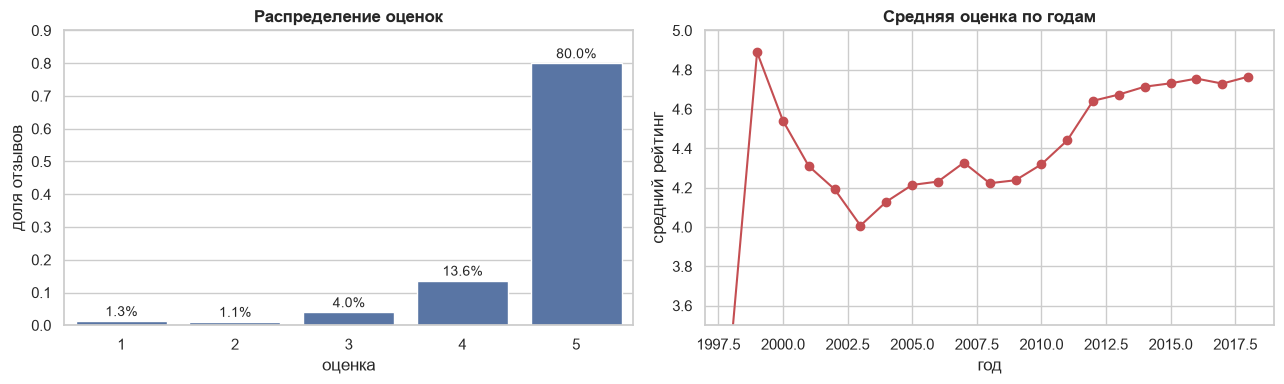

rating
1.0    0.0129
2.0    0.0107
3.0    0.0400
4.0    0.1363
5.0    0.8001


In [10]:
rating_dist = data[RATING_COL].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=rating_dist.index.astype(int), y=rating_dist.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("Распределение оценок")
axes[0].set_xlabel("оценка")
axes[0].set_ylabel("доля отзывов")
axes[0].set_ylim(0, 0.9)
for i, v in enumerate(rating_dist.values):
    axes[0].text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

mean_by_year = data.groupby(data["date"].dt.year)[RATING_COL].agg(["mean", "size"])
axes[1].plot(mean_by_year.index, mean_by_year["mean"], marker="o", color="#C44E52")
axes[1].set_title("Средняя оценка по годам")
axes[1].set_xlabel("год")
axes[1].set_ylabel("средний рейтинг")
axes[1].set_ylim(3.5, 5)

plt.tight_layout()
plt.show()

print(rating_dist.round(4).to_string())

Наблюдается **перекос в сторону пятёрок**: 80 % оценок — «5», ещё 13.6 % — «4»,
негативных отзывов (1–2) меньше 2.5 %.

Практический вывод: **явный (explicit) сигнал здесь почти бесполезен** — предсказывать «оценку»
в такой выборке означает предсказывать константу 5. Гораздо информативнее сам **факт взаимодействия**
(человек купил/послушал альбом и вообще написал отзыв), поэтому дальше решаем задачу
как **implicit feedback**: матрица «пользователь × товар» из нулей и единиц.

### 3.3 Активность пользователей и популярность товаров

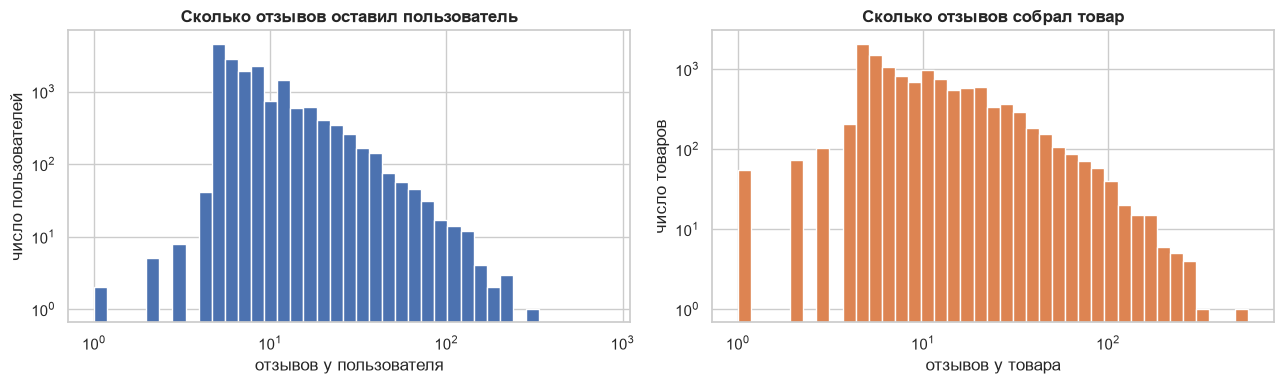

,отзывов у пользователя,отзывов у товара
count,16566.00,11797.00
mean,10.25,14.39
std,12.38,18.79
min,1.00,1.00
25%,5.00,6.00
50%,7.00,9.00
75%,11.00,15.00
max,791.00,574.00


In [11]:
user_activity = data.groupby(USER_COL).size()
item_popularity = data.groupby(ITEM_COL).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_activity, bins=np.logspace(0, np.log10(user_activity.max()), 40), color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Сколько отзывов оставил пользователь")
axes[0].set_xlabel("отзывов у пользователя")
axes[0].set_ylabel("число пользователей")

axes[1].hist(item_popularity, bins=np.logspace(0, np.log10(item_popularity.max()), 40), color="#DD8452")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Сколько отзывов собрал товар")
axes[1].set_xlabel("отзывов у товара")
axes[1].set_ylabel("число товаров")

plt.tight_layout()
plt.show()

pd.concat(
    [user_activity.describe(), item_popularity.describe()],
    axis=1, keys=["отзывов у пользователя", "отзывов у товара"],
).round(2)

 Половина пользователей оставила не больше 7 отзывов,
при этом самый активный оставил почти восемьсот.

### 3.4 Long tail: какая доля спроса приходится на топ товаров

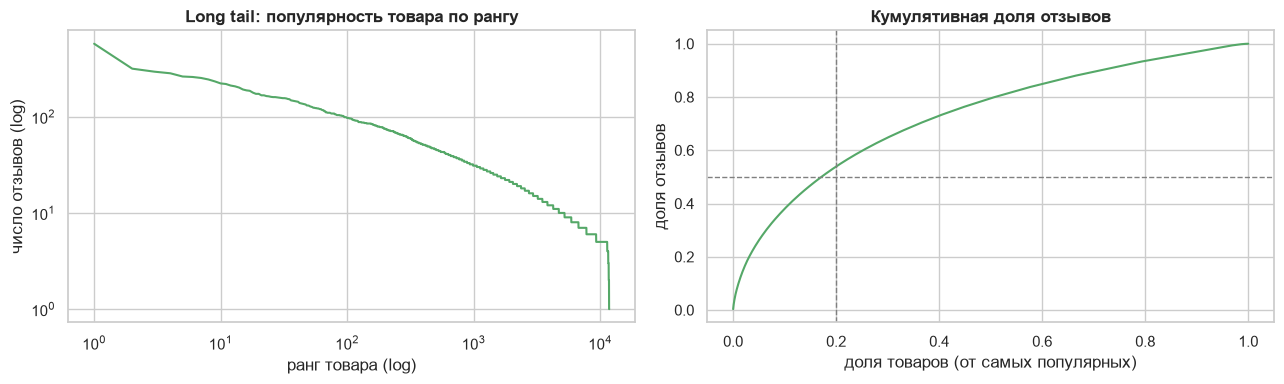

топ-1% товаров (  117 шт.) собирают 9.7% всех отзывов
топ-5% товаров (  589 шт.) собирают 26.1% всех отзывов
топ-10% товаров ( 1179 шт.) собирают 38.0% всех отзывов
топ-20% товаров ( 2359 шт.) собирают 53.9% всех отзывов


In [12]:
sorted_pop = item_popularity.sort_values(ascending=False).values
cum_share = np.cumsum(sorted_pop) / sorted_pop.sum()
item_share = np.arange(1, len(sorted_pop) + 1) / len(sorted_pop)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, len(sorted_pop) + 1), sorted_pop, color="#55A868")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Long tail: популярность товара по рангу")
axes[0].set_xlabel("ранг товара (log)")
axes[0].set_ylabel("число отзывов (log)")

axes[1].plot(item_share, cum_share, color="#55A868")
axes[1].axhline(0.5, ls="--", c="grey", lw=1)
axes[1].axvline(0.2, ls="--", c="grey", lw=1)
axes[1].set_title("Кумулятивная доля отзывов")
axes[1].set_xlabel("доля товаров (от самых популярных)")
axes[1].set_ylabel("доля отзывов")

plt.tight_layout()
plt.show()

for q in (0.01, 0.05, 0.1, 0.2):
    k = int(len(sorted_pop) * q)
    print(f"топ-{q:.0%} товаров ({k:5d} шт.) собирают {cum_share[k - 1]:.1%} всех отзывов")

На топ-20 % товаров приходится примерно половина всех отзывов — хвост длинный и «толстый».
Это уже подсказывает, что модель, рекомендующая только популярное, будет иметь
**крайне низкий coverage** и не поможет пользователю найти что-то новое.

### 3.5 Динамика по годам и топ товаров

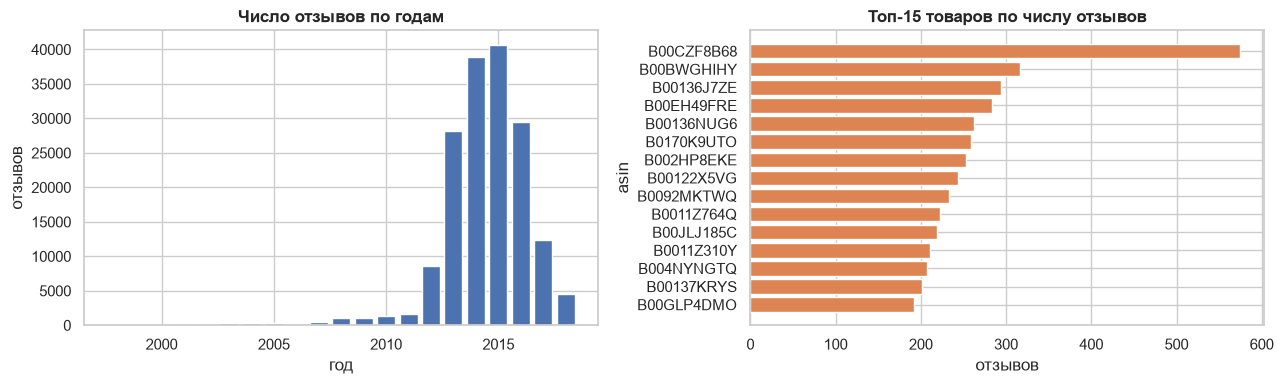

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

by_year = data.groupby(data["date"].dt.year).size()
axes[0].bar(by_year.index, by_year.values, color="#4C72B0")
axes[0].set_title("Число отзывов по годам")
axes[0].set_xlabel("год")
axes[0].set_ylabel("отзывов")

top_items = item_popularity.sort_values(ascending=False).head(15)
axes[1].barh(top_items.index[::-1], top_items.values[::-1], color="#DD8452")
axes[1].set_title("Топ-15 товаров по числу отзывов")
axes[1].set_xlabel("отзывов")
axes[1].set_ylabel("asin")

plt.tight_layout()
plt.show()

Данные покрывают период с конца 1990-х по 2018 год, но основная масса отзывов приходится на 2013–2016 годы.

###  Выводы по EDA

1. **169 781 отзыв, 16 566 пользователей, 11 797 товаров**, разреженность 99.91 %.
2. Оценки сильно смещены вверх (80 % пятёрок) → работаем с **implicit feedback**, а не с предсказанием рейтинга.
3. Есть **24 489 дубликатов** пар `(user, item)` — их нужно схлопнуть.
4. И активность пользователей, и популярность товаров распределены по степенному закону → у большинства
   пользователей очень короткая история, поэтому метрики будут невысокими по абсолютной величине,
   а разница между моделями — заметной.

## 4. Предобработка

In [17]:
def deduplicate(df: pd.DataFrame) -> pd.DataFrame:
    # оставляем последнее по времени взаимодействие для каждой пары (user, item)
    return (
        df.sort_values(TIME_COL)
          .drop_duplicates(subset=[USER_COL, ITEM_COL], keep="last")
          .reset_index(drop=True)
    )


def filter_data(df: pd.DataFrame, user_count: int = 5, item_count: int = 5) -> pd.DataFrame:
    # итеративный k-core: у каждого пользователя >= user_count, у каждого товара >= item_count
    while True:
        size_before = len(df)

        items = df.groupby(ITEM_COL)[USER_COL].count()
        df = df[df[ITEM_COL].isin(items[items >= item_count].index)]

        users = df.groupby(USER_COL)[ITEM_COL].count()
        df = df[df[USER_COL].isin(users[users >= user_count].index)]

        if len(df) == size_before:
            return df.reset_index(drop=True)


df_clean = filter_data(deduplicate(data))

stats = pd.DataFrame(
    {
        "исходные": [len(data), data[USER_COL].nunique(), data[ITEM_COL].nunique()],
        "после дедупл. + 5-core": [len(df_clean), df_clean[USER_COL].nunique(), df_clean[ITEM_COL].nunique()],
    },
    index=["взаимодействий", "пользователей", "товаров"],
)
stats["потеряли, %"] = (100 * (1 - stats["после дедупл. + 5-core"] / stats["исходные"])).round(1)
stats

,исходные,после дедупл. + 5-core,"потеряли, %"
взаимодействий,169781,123518,27.2
пользователей,16566,12381,25.3
товаров,11797,9906,16.0


## 5. Train/test split методом leave-one-out

Для каждого пользователя сортируем его историю по времени и убираем **последнее**
взаимодействие в тест. Разбиение по времени внутри пользователя, а не случайное, —
принципиально: случайный split подсматривает будущее и завышает метрики.

**Второй leave-one-out — для валидации.** Гиперпараметры нельзя подбирать по тесту,поэтому режем ещё раз: предпоследнее взаимодействие каждого пользователя —
это валидация.

* на `train_core` учим модели и подбираем гиперпараметры по `val`;
* с лучшими гиперпараметрами переобучаем на `train_full` и **один раз** считаем метрики на `test`.

Из holdout-выборок выбрасываем товары, которых нет в соответствующем train

In [18]:
def leave_one_out(df: pd.DataFrame):
    # последнее по времени взаимодействие каждого пользователя -> holdout, остальное -> train
    df = df.sort_values([USER_COL, TIME_COL, ITEM_COL])
    holdout_idx = df.groupby(USER_COL).tail(1).index
    holdout = df.loc[holdout_idx].reset_index(drop=True)
    train = df.drop(holdout_idx).reset_index(drop=True)
    return train, holdout


train_full, test = leave_one_out(df_clean)   # test = последний товар пользователя
train_core, val = leave_one_out(train_full)  # val  = предпоследний товар

print(f"train_core : {len(train_core):>7,} взаимодействий")
print(f"val        : {len(val):>7,}")
print(f"train_full : {len(train_full):>7,}")
print(f"test       : {len(test):>7,}")

train_core :  98,756 взаимодействий
val        :  12,381
train_full : 111,137
test       :  12,381


### Матрица взаимодействий

Класс для итераций: сквозная нумерация id, sparse-матрица, фильтрация holdout). Матрицу строим **бинарной**: как показал EDA

In [21]:
class Interactions:
    # разреженная матрица user x item + маппинг внешних id во внутренние индексы

    def __init__(self, train_df: pd.DataFrame):
        self.train = train_df.copy()
        self.train["uid"], self.user_uniques = pd.factorize(self.train[USER_COL])
        self.train["iid"], self.item_uniques = pd.factorize(self.train[ITEM_COL])

        self.user2id = {u: i for i, u in enumerate(self.user_uniques)}
        self.item2id = {it: j for j, it in enumerate(self.item_uniques)}
        self.id2user = dict(enumerate(self.user_uniques))
        self.id2item = dict(enumerate(self.item_uniques))

        self.n_users = len(self.user_uniques)
        self.n_items = len(self.item_uniques)

        # бинарная матрица: 1 = взаимодействие было
        self.R = sp.csr_matrix(
            (np.ones(len(self.train), dtype=np.float32), (self.train["uid"], self.train["iid"])),
            shape=(self.n_users, self.n_items),
        )

    def prepare_holdout(self, holdout_df: pd.DataFrame) -> pd.DataFrame:
        # оставляем только тех пользователей и те товары, которые модель видела на обучении
        hold = holdout_df[
            holdout_df[USER_COL].isin(self.user2id) & holdout_df[ITEM_COL].isin(self.item2id)
        ].copy()
        hold["uid"] = hold[USER_COL].map(self.user2id)
        hold["iid"] = hold[ITEM_COL].map(self.item2id)
        return hold.reset_index(drop=True)

    @property
    def sparsity(self) -> float:
        return 100 * (1 - self.R.nnz / (self.n_users * self.n_items))

    def __repr__(self):
        return (f"Interactions(users={self.n_users}, items={self.n_items}, "
                f"nnz={self.R.nnz}, sparsity={self.sparsity:.2f}%)")


ds_core = Interactions(train_core)   # для подбора гиперпараметров
ds_full = Interactions(train_full)   # для финальной оценки

val_eval = ds_core.prepare_holdout(val)
test_eval = ds_full.prepare_holdout(test)

print(ds_core)
print(ds_full)
print(f"\nвалидация: {len(val_eval):,} пользователей из {len(val):,} "
      f"({len(val_eval) / len(val):.1%}; остальные загаданы на товарах, которых нет в train_core)")
print(f"тест     : {len(test_eval):,} пользователей из {len(test):,} "
      f"({len(test_eval) / len(test):.1%})")

Interactions(users=12381, items=9888, nnz=98756, sparsity=99.92%)
Interactions(users=12381, items=9904, nnz=111137, sparsity=99.91%)

валидация: 12,346 пользователей из 12,381 (99.7%; остальные загаданы на товарах, которых нет в train_core)
тест     : 12,371 пользователей из 12,381 (99.9%)


## 6. Метрики качества

Все метрики считаем на топ-10 рекомендаций. В leave-one-out у каждого пользователя ровно **один**
релевантный товар

In [24]:
def hr(pred_df: pd.DataFrame, pred_col: str = "preds", true_col: str = "true") -> float:
    return np.mean([true in preds for true, preds in zip(pred_df[true_col], pred_df[pred_col])])


def mrr(pred_df: pd.DataFrame, pred_col: str = "preds", true_col: str = "true") -> float:
    return np.mean([
        1 / (preds.index(true) + 1) if true in preds else 0
        for true, preds in zip(pred_df[true_col], pred_df[pred_col])
    ])


def ndcg(pred_df: pd.DataFrame, pred_col: str = "preds", true_col: str = "true") -> float:
    # ideal DCG == 1, т.к. в leave-one-out ровно один релевантный товар
    return np.mean([
        1 / np.log2(preds.index(true) + 2) if true in preds else 0
        for true, preds in zip(pred_df[true_col], pred_df[pred_col])
    ])


def coverage(pred_df: pd.DataFrame, n_train_items: int, pred_col: str = "preds") -> float:
    recommended = set().union(*pred_df[pred_col])
    return len(recommended) / n_train_items


def calculate_metrics(pred_df: pd.DataFrame, n_train_items: int, k: int = TOP_K) -> dict:
    return {
        f"HR@{k}": hr(pred_df),
        f"MRR@{k}": mrr(pred_df),
        f"NDCG@{k}": ndcg(pred_df),
        f"Coverage@{k}": coverage(pred_df, n_train_items),
    }

### Общий каркас для всех моделей

Чтобы модели сравнивались честно, все они проходят через одну и ту же процедуру:

1. посчитать скоры всех товаров для пользователей из holdout;
2. **занулить уже просмотренное** — рекомендовать то, что человек уже купил, бессмысленно;
3. взять топ-10 и собрать `DataFrame` со столбцом `preds` (список item-ов) — ровно тот формат, который ждут метрики.

Скоры считаем батчами по 2 000 пользователей.

In [25]:
def top_k_from_scores(scores: np.ndarray, uids: np.ndarray, R: sp.csr_matrix, k: int = TOP_K) -> np.ndarray:
    # из плотной матрицы скоров (batch x n_items) достаём топ-k, исключая уже увиденное
    seen = R[uids].toarray() > 0
    scores = np.where(seen, -np.inf, scores)
    idx = np.argpartition(-scores, k, axis=1)[:, :k]              # k лучших без сортировки
    order = np.argsort(-np.take_along_axis(scores, idx, axis=1))  # сортируем только их
    return np.take_along_axis(idx, order, axis=1)


def build_predictions(top_items: np.ndarray, holdout: pd.DataFrame) -> pd.DataFrame:
    # top_items (n_users x k, внутренние iid) -> DataFrame с колонками true / preds
    return pd.DataFrame({
        "uid": holdout["uid"].to_numpy(),
        "true": holdout["iid"].to_numpy(),
        "preds": [list(row) for row in top_items],
    })


def evaluate(score_fn, ds: "Interactions", holdout: pd.DataFrame,
             k: int = TOP_K, batch_size: int = 2000, name: str = ""):
    # score_fn(uids) -> плотная матрица скоров размера (len(uids) x n_items)
    t0 = time.time()
    uids = holdout["uid"].to_numpy()

    tops = []
    for start in range(0, len(uids), batch_size):
        batch = uids[start:start + batch_size]
        scores = np.asarray(score_fn(batch), dtype=np.float32)
        tops.append(top_k_from_scores(scores, batch, ds.R, k))

    pred_df = build_predictions(np.vstack(tops), holdout)
    metrics = calculate_metrics(pred_df, ds.n_items, k)
    if name:
        print(f"{name:<26}" + "   ".join(f"{key}={value:.4f}" for key, value in metrics.items())
              + f"   [{time.time() - t0:.1f} s]")
    return pred_df, metrics

## 7. Модели

| Модель | Идея | Персонализация |
|---|---|---|
| **Random** | случайные 10 товаров | нет (нижняя граница) |
| **Top-Popular** | самые популярные товары каталога | нет (бейзлайн из задания) |
| **ItemKNN** | «с этим товаром обычно берут…» — косинусная близость товаров по со-встречаемости | да, по истории пользователя |
| **ALS** | матричная факторизация неявного отклика (`implicit`) | да, через латентные факторы |
| **BPR** | факторизация с попарным ранжирующим лоссом (`implicit`) | да, оптимизирует именно порядок |

### 7.1 Random — нижняя граница

Нужен, чтобы понимать масштаб: если модель работает на уровне случайного выбора, значит она не работает.
При каталоге в ~10 000 товаров случайный HR@10 должен быть около $10/10000 = 0.001$.

In [26]:
def random_scores_factory(n_items: int, seed: int = RANDOM_STATE):
    generator = np.random.default_rng(seed)

    def score_fn(uids):
        return generator.random((len(uids), n_items))

    return score_fn


pred_random_val, m_random_val = evaluate(
    random_scores_factory(ds_core.n_items), ds_core, val_eval, name="Random (val)"
)

Random (val)              HR@10=0.0012   MRR@10=0.0004   NDCG@10=0.0006   Coverage@10=1.0000   [1.0 s]


### 7.2 Top-Popular

Скор товара = число пользователей, купивших его в train. Он одинаков для всех, персонализация возникает
только за счёт фильтрации уже просмотренного (как в семинарском ноутбуке `RECO_SYS_knn`).

In [28]:
def popularity_scores_factory(ds: "Interactions"):
    popularity = np.asarray(ds.R.sum(axis=0)).ravel()   # число покупок каждого товара

    def score_fn(uids):
        return np.tile(popularity, (len(uids), 1))

    return score_fn


pred_pop_val, m_pop_val = evaluate(
    popularity_scores_factory(ds_core), ds_core, val_eval, name="Top-Popular (val)"
)

Top-Popular (val)         HR@10=0.0249   MRR@10=0.0100   NDCG@10=0.0134   Coverage@10=0.0018   [0.7 s]


### 7.3 ItemKNN на косинусной близости

Считаем всё на разреженных матрицах, без единой плотной матрицы 10 000 × 10 000:

1. нормируем столбцы матрицы взаимодействий
2. косинусная близость всех пар товаров, обнуляем диагональ
   (иначе товар будет «похож» сам на себя и рекомендации выродятся в уже просмотренное);
3. **оставляем у каждого товара только $K$ ближайших соседей** — это и регуляризация (отсекаем
   шумные слабые связи), и экономия памяти;
4. скор пользователя: сумма похожестей его товаров на кандидата.

In [38]:
class ItemKNN:
    # item-based CF: косинусная близость товаров по со-встречаемости у пользователей

    def __init__(self, k_neighbors: int = 50):
        self.k_neighbors = k_neighbors
        self.similarity = None

    @staticmethod
    def _keep_top_k(S: sp.csr_matrix, k: int) -> sp.csr_matrix:
        # в каждой строке оставляем только k самых близких соседей
        indptr, indices, values = [0], [], []
        for row in range(S.shape[0]):
            start, end = S.indptr[row], S.indptr[row + 1]
            row_values, row_indices = S.data[start:end], S.indices[start:end]
            if len(row_values) > k:
                keep = np.argpartition(-row_values, k)[:k]
                row_values, row_indices = row_values[keep], row_indices[keep]
            values.append(row_values)
            indices.append(row_indices)
            indptr.append(indptr[-1] + len(row_values))
        return sp.csr_matrix(
            (np.concatenate(values), np.concatenate(indices), np.array(indptr)), shape=S.shape
        )

    def fit(self, R: sp.csr_matrix):
        item_vectors = normalize(R.T.tocsr())        # items x users, L2-нормировка строк
        S = (item_vectors @ item_vectors.T).tocsr()  # косинус между всеми парами товаров
        S.setdiag(0)
        S.eliminate_zeros()
        self.similarity = self._keep_top_k(S, self.k_neighbors)
        return self

    def score_factory(self, R: sp.csr_matrix):
        def score_fn(uids):
            return (R[uids] @ self.similarity).toarray()

        return score_fn


%time knn_probe = ItemKNN(k_neighbors=50).fit(ds_core.R)
print("ненулевых связей в матрице похожести:", f"{knn_probe.similarity.nnz:,}")

CPU times: total: 31.2 ms
Wall time: 56.9 ms
ненулевых связей в матрице похожести: 458,930


**Подбираем число соседей $K$ по валидации.**

In [39]:
knn_grid = []
for k_neighbors in [10, 20, 50, 100, 200, 500]:
    model = ItemKNN(k_neighbors=k_neighbors).fit(ds_core.R)
    _, metrics = evaluate(model.score_factory(ds_core.R), ds_core, val_eval)
    knn_grid.append({"k_neighbors": k_neighbors, **metrics})

knn_grid = pd.DataFrame(knn_grid).set_index("k_neighbors")
best_knn_k = int(knn_grid[f"NDCG@{TOP_K}"].idxmax())
print(f"лучшее число соседей по NDCG@{TOP_K}: {best_knn_k}")
knn_grid.round(4)

лучшее число соседей по NDCG@10: 500


,HR@10,MRR@10,NDCG@10,Coverage@10
k_neighbors,,,,
10,0.1035,0.0577,0.0684,0.8829
20,0.1037,0.0575,0.0684,0.8897
50,0.1021,0.0571,0.0677,0.9135
100,0.1017,0.0574,0.0678,0.9293
200,0.1056,0.0582,0.0693,0.9355
500,0.1069,0.0594,0.0706,0.9406


Качество почти не зависит от $K$: кривая пологая, разница между 10 и 500 соседями — в третьем знаке.
Зато **coverage растёт вместе с $K$**: чем больше соседей учитывается, тем чаще в выдачу попадают
товары из хвоста. Поэтому берём большое $K$ — оно не хуже по точности и заметно лучше по разнообразию.

### 7.4 ALS — матричная факторизация неявного отклика

Модель раскладывает матрицу взаимодействий на латентные факторы пользователей и товаров, а обучается по схеме
Alternating Least Squares — поочерёдно фиксируем $Q$ и решаем задачу наименьших квадратов для $P$, и наоборот.

Ключевой момент implicit-версии (Hu, Koren, Volinsky): нули матрицы — это не «не нравится»,
а «не знаем». Поэтому в лосс входят **все** пары $(u, i)$, но с разным весом доверия
$c_{ui} = 1 + \alpha \cdot r_{ui}$. Параметр $\alpha$ задаёт, насколько сильнее мы верим
наблюдённым взаимодействиям, чем нулям, — в `implicit` он задаётся просто умножением матрицы
на константу (как в семинаре `recsys_mf_practice`).

Подбираем `factors` и `alpha` по валидации.

In [40]:
def fit_als(R: sp.csr_matrix, factors: int = 128, alpha: float = 40.0,
            regularization: float = 0.1, iterations: int = 30):
    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        use_gpu=False,
        random_state=RANDOM_STATE,
    )
    model.fit(R * alpha, show_progress=False)   # alpha = уровень доверия наблюдённым взаимодействиям
    return model


def factors_score_factory(model):
    # общий scorer для ALS и BPR: скор = скалярное произведение латентных векторов
    user_factors = np.asarray(model.user_factors)
    item_factors = np.asarray(model.item_factors)

    def score_fn(uids):
        return user_factors[uids] @ item_factors.T

    return score_fn

In [41]:
%%time
als_grid = []
for factors in [64, 128, 256]:
    for alpha in [20, 40, 80]:
        model = fit_als(ds_core.R, factors=factors, alpha=alpha)
        _, metrics = evaluate(factors_score_factory(model), ds_core, val_eval)
        als_grid.append({"factors": factors, "alpha": alpha, **metrics})

als_grid = pd.DataFrame(als_grid)
best_als = als_grid.loc[als_grid[f"NDCG@{TOP_K}"].idxmax()]
print(f"лучшие параметры ALS: factors={int(best_als.factors)}, alpha={int(best_als.alpha)}")
als_grid.set_index(["factors", "alpha"]).round(4)

лучшие параметры ALS: factors=256, alpha=20
CPU times: total: 3min 17s
Wall time: 1min 28s


HR@10  MRR@10  NDCG@10  Coverage@10
factors alpha                                      
64      20     0.0965  0.0400   0.0532       0.2631
        40     0.0981  0.0401   0.0536       0.3410
        80     0.1008  0.0408   0.0548       0.4355
128     20     0.1157  0.0505   0.0657       0.4445
        40     0.1174  0.0525   0.0676       0.5710
        80     0.1166  0.0527   0.0677       0.7070
256     20     0.1231  0.0575   0.0728       0.7039
        40     0.1214  0.0578   0.0726       0.8307
        80     0.1164  0.0570   0.0709       0.9035

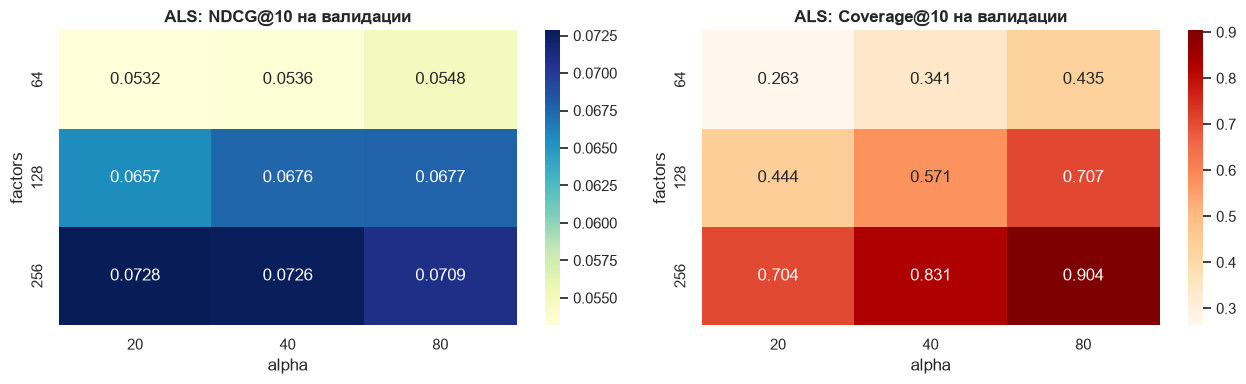

In [42]:
pivot = als_grid.pivot(index="factors", columns="alpha", values=f"NDCG@{TOP_K}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title(f"ALS: NDCG@{TOP_K} на валидации")

pivot_cov = als_grid.pivot(index="factors", columns="alpha", values=f"Coverage@{TOP_K}")
sns.heatmap(pivot_cov, annot=True, fmt=".3f", cmap="OrRd", ax=axes[1])
axes[1].set_title(f"ALS: Coverage@{TOP_K} на валидации")

plt.tight_layout()
plt.show()

### 7.5 BPR — попарное ранжирование

BPR (Bayesian Personalized Ranking) оптимизирует не восстановление матрицы, а **порядок**:
для каждого наблюдённого взаимодействия $(u, i)$ сэмплируется случайный «негатив» $j$,
и максимизируется $\ln \sigma(\hat x_{ui} - \hat x_{uj})$. По постановке это ближе к тому,
что мы измеряем метриками ранжирования.

In [34]:
%%time
def fit_bpr(R: sp.csr_matrix, factors: int = 128, learning_rate: float = 0.05,
            regularization: float = 0.01, iterations: int = 150):
    model = implicit.bpr.BayesianPersonalizedRanking(
        factors=factors,
        learning_rate=learning_rate,
        regularization=regularization,
        iterations=iterations,
        random_state=RANDOM_STATE,
        verify_negative_samples=True,
        num_threads=1,   # SGD в implicit асинхронный: один поток нужен для воспроизводимости
    )
    model.fit(R, show_progress=False)
    return model


bpr_grid = []
for factors in [64, 128, 256]:
    model = fit_bpr(ds_core.R, factors=factors)
    _, metrics = evaluate(factors_score_factory(model), ds_core, val_eval)
    bpr_grid.append({"factors": factors, **metrics})

bpr_grid = pd.DataFrame(bpr_grid).set_index("factors")
best_bpr_factors = int(bpr_grid[f"NDCG@{TOP_K}"].idxmax())
print(f"лучшее число факторов BPR: {best_bpr_factors}")
bpr_grid.round(4)

лучшее число факторов BPR: 128
CPU times: total: 18.3 s
Wall time: 17.9 s


,HR@10,MRR@10,NDCG@10,Coverage@10
factors,,,,
64,0.0741,0.0320,0.0418,0.9280
128,0.0774,0.0343,0.0443,0.9223
256,0.0756,0.0331,0.0430,0.9098


BPR заметно проигрывает и ALS, и ItemKNN, причём увеличение размерности ему не помогает. Чтобы вытащить BPR, нужны
взвешенное сэмплирование негативов и  более аккуратный подбор `learning_rate` / числа эпох;
ALS на неявном отклике добивается лучшего результата практически «из коробки».

## 8. Финальная оценка на тесте

Переобучаем все модели с подобранными гиперпараметрами на `train_full` (train_core + val)
и **один раз** считаем метрики на отложенном тесте.

In [35]:
%%time
results = {}
predictions = {}

# 1. Random
predictions["Random"], results["Random"] = evaluate(
    random_scores_factory(ds_full.n_items), ds_full, test_eval, name="Random"
)

# 2. Top-Popular
predictions["Top-Popular"], results["Top-Popular"] = evaluate(
    popularity_scores_factory(ds_full), ds_full, test_eval, name="Top-Popular"
)

# 3. ItemKNN
knn_final = ItemKNN(k_neighbors=best_knn_k).fit(ds_full.R)
predictions["ItemKNN"], results["ItemKNN"] = evaluate(
    knn_final.score_factory(ds_full.R), ds_full, test_eval, name=f"ItemKNN (K={best_knn_k})"
)

# 4. ALS
als_final = fit_als(ds_full.R, factors=int(best_als.factors), alpha=float(best_als.alpha))
predictions["ALS"], results["ALS"] = evaluate(
    factors_score_factory(als_final), ds_full, test_eval,
    name=f"ALS (f={int(best_als.factors)}, a={int(best_als.alpha)})"
)

# 5. BPR
bpr_final = fit_bpr(ds_full.R, factors=best_bpr_factors)
predictions["BPR"], results["BPR"] = evaluate(
    factors_score_factory(bpr_final), ds_full, test_eval, name=f"BPR (f={best_bpr_factors})"
)

Random                    HR@10=0.0006   MRR@10=0.0001   NDCG@10=0.0002   Coverage@10=1.0000   [1.1 s]
Top-Popular               HR@10=0.0237   MRR@10=0.0089   NDCG@10=0.0123   Coverage@10=0.0019   [0.7 s]
ItemKNN (K=500)           HR@10=0.1131   MRR@10=0.0653   NDCG@10=0.0765   Coverage@10=0.9383   [0.9 s]
ALS (f=256, a=20)         HR@10=0.1191   MRR@10=0.0578   NDCG@10=0.0722   Coverage@10=0.6945   [0.9 s]
BPR (f=128)               HR@10=0.0750   MRR@10=0.0325   NDCG@10=0.0424   Coverage@10=0.9300   [0.7 s]
CPU times: total: 24.4 s
Wall time: 34 s


In [43]:
results_df = pd.DataFrame(results).T
results_df["uplift к Top-Popular, HR"] = (
    results_df[f"HR@{TOP_K}"] / results_df.loc["Top-Popular", f"HR@{TOP_K}"]
).round(1)

results_df.sort_values(f"NDCG@{TOP_K}", ascending=False).style.background_gradient(
    cmap="Greens", subset=[f"HR@{TOP_K}", f"MRR@{TOP_K}", f"NDCG@{TOP_K}"]
).format("{:.4f}", subset=[f"HR@{TOP_K}", f"MRR@{TOP_K}", f"NDCG@{TOP_K}", f"Coverage@{TOP_K}"])

,HR@10,MRR@10,NDCG@10,Coverage@10,"uplift к Top-Popular, HR"
ItemKNN,0.1131,0.0653,0.0765,0.9383,4.800000
ALS,0.1191,0.0578,0.0722,0.6945,5.000000
BPR,0.0750,0.0325,0.0424,0.9300,3.200000
Top-Popular,0.0237,0.0089,0.0123,0.0019,1.000000
Random,0.0006,0.0001,0.0002,1.0000,0.000000


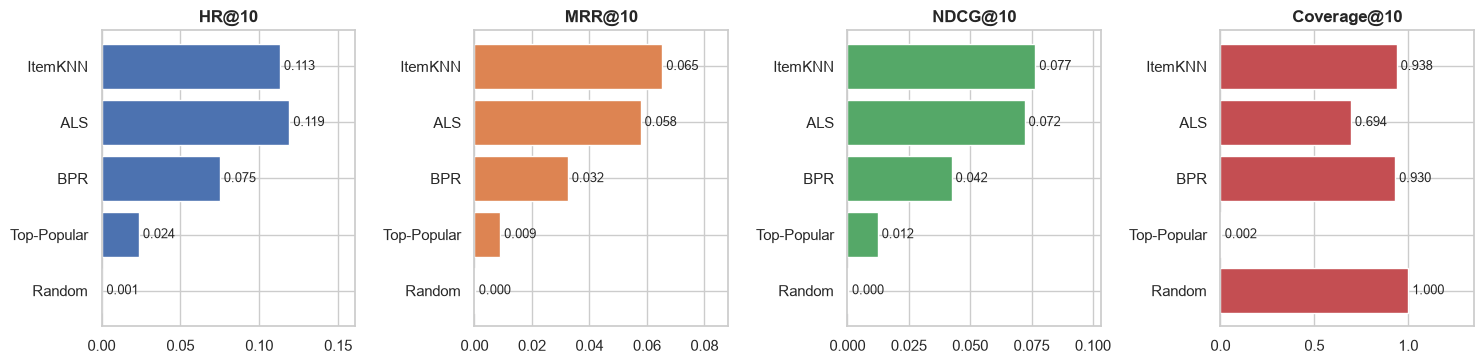

In [44]:
order = results_df.sort_values(f"NDCG@{TOP_K}").index
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

for ax, metric, color in zip(
    axes,
    [f"HR@{TOP_K}", f"MRR@{TOP_K}", f"NDCG@{TOP_K}", f"Coverage@{TOP_K}"],
    ["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
):
    values = results_df.loc[order, metric]
    ax.barh(order, values, color=color)
    ax.set_title(metric)
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)
    ax.set_xlim(0, values.max() * 1.35)

plt.tight_layout()
plt.show()

ALS и ItemKNN идут вровень, и метрики у них разошлись в разные стороны: у ALS выше HR,
у ItemKNN — MRR и NDCG. Проверим, не шум ли это.
Метрика — среднее по 12 тысячам пользователей, и обе модели оцениваются **на одних и тех же**
пользователях, поэтому используем парный бутстрэп: многократно пересобираем выборку пользователей
с возвращением и смотрим на распределение разницы метрик.

In [45]:
def per_user_scores(pred_df: pd.DataFrame) -> dict:
    ranks = np.array([
        preds.index(true) + 1 if true in preds else 0
        for true, preds in zip(pred_df["true"], pred_df["preds"])
    ])
    hit = ranks > 0
    return {
        f"HR@{TOP_K}": hit.astype(float),
        f"MRR@{TOP_K}": np.where(hit, 1 / np.maximum(ranks, 1), 0.0),
        f"NDCG@{TOP_K}": np.where(hit, 1 / np.log2(np.maximum(ranks, 1) + 1), 0.0),
    }


def paired_bootstrap(pred_a, pred_b, n_boot: int = 2000, seed: int = RANDOM_STATE) -> pd.DataFrame:
    generator = np.random.default_rng(seed)
    scores_a, scores_b = per_user_scores(pred_a), per_user_scores(pred_b)
    n = len(pred_a)
    idx = generator.integers(0, n, size=(n_boot, n))

    rows = []
    for metric in scores_a:
        diff = scores_a[metric] - scores_b[metric]           # разница по каждому пользователю
        boot = diff[idx].mean(axis=1)                        # распределение средней разницы
        low, high = np.percentile(boot, [2.5, 97.5])
        rows.append({
            "метрика": metric,
            "разница": diff.mean(),
            "95% ДИ снизу": low,
            "95% ДИ сверху": high,
            "значимо": "да" if low * high > 0 else "нет",
        })
    return pd.DataFrame(rows).set_index("метрика").round(4)


print("ItemKNN минус ALS (положительное значение = ItemKNN лучше)")
paired_bootstrap(predictions["ItemKNN"], predictions["ALS"])

ItemKNN минус ALS (положительное значение = ItemKNN лучше)


,разница,95% ДИ снизу,95% ДИ сверху,значимо
метрика,,,,
HR@10,-0.0060,-0.0108,-0.0015,да
MRR@10,0.0075,0.0044,0.0105,да
NDCG@10,0.0044,0.0012,0.0074,да


### Точность против разнообразия

Посмотрим на популярность рекомендованных товаров: если модель просто подсовывает всем хиты,
средний ранг популярности её рекомендаций будет близок к нулю.

In [48]:
popularity_full = np.asarray(ds_full.R.sum(axis=0)).ravel()
popularity_rank = pd.Series(popularity_full).rank(ascending=False, method="first").to_numpy()

profile = []
for name, pred_df in predictions.items():
    recommended = np.concatenate(pred_df["preds"].to_list())
    profile.append({
        "модель": name,
        "медианный ранг популярности рекомендаций": int(np.median(popularity_rank[recommended])),
        "медианное число покупок товара": int(np.median(popularity_full[recommended])),
        "уникальных товаров в выдаче": len(np.unique(recommended)),
        f"Coverage@{TOP_K}": round(results[name][f"Coverage@{TOP_K}"], 4),
    })

pd.DataFrame(profile).set_index("модель")

,медианный ранг популярности рекомендаций,медианное число покупок товара,уникальных товаров в выдаче,Coverage@10
модель,,,,
Random,4968,7,9904,1.0000
Top-Popular,6,175,19,0.0019
ItemKNN,4861,7,9293,0.9383
ALS,771,24,6878,0.6945
BPR,3513,10,9211,0.9300


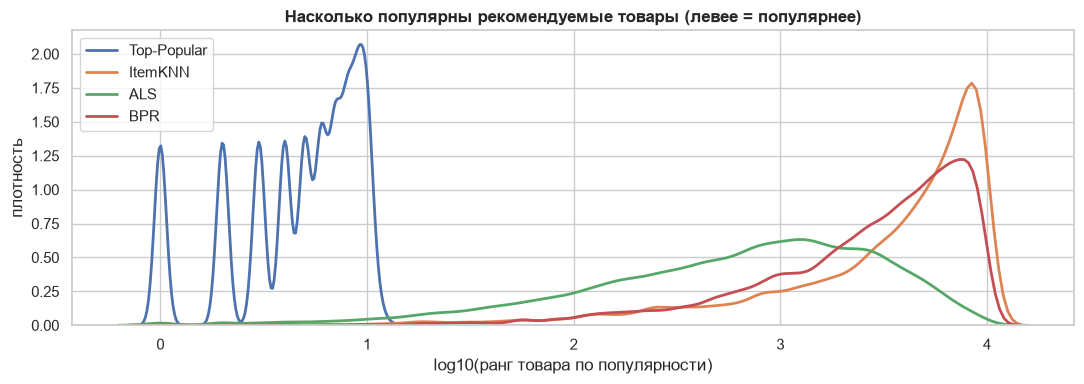

In [49]:
fig, ax = plt.subplots(figsize=(11, 4))

for name, pred_df in predictions.items():
    if name == "Random":
        continue
    recommended = np.concatenate(pred_df["preds"].to_list())
    sns.kdeplot(np.log10(popularity_rank[recommended]), label=name, ax=ax, lw=2)

ax.set_title("Насколько популярны рекомендуемые товары (левее = популярнее)")
ax.set_xlabel("log10(ранг товара по популярности)")
ax.set_ylabel("плотность")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Как выглядят рекомендации

В файле с отзывами нет названий товаров, только `asin`, поэтому смотрим на карточку товара по ссылке
`amazon.com/dp/<asin>`. Возьмём активного пользователя и сравним, что советуют разные модели.

In [50]:
# ищем показательный пример: пользователь с внятной историей, которому ALS угадал тестовый товар
history_size = ds_full.train.groupby("uid").size()
als_hits = predictions["ALS"].assign(
    hit=[true in preds for true, preds in zip(predictions["ALS"]["true"], predictions["ALS"]["preds"])]
)
candidates = als_hits.query("hit")
candidates = candidates[candidates["uid"].isin(history_size[history_size.between(10, 30)].index)]

example_uid = int(candidates["uid"].iloc[0])
example_true = int(test_eval.query("uid == @example_uid")["iid"].iloc[0])

user_history = ds_full.train.query("uid == @example_uid").sort_values(TIME_COL)

print(f"пользователь {ds_full.id2user[example_uid]} — {len(user_history)} товаров в истории")
print(f"загаданный (тестовый) товар: {ds_full.id2item[example_true]}")
user_history[[ITEM_COL, RATING_COL, "date"]].tail(8).reset_index(drop=True)

пользователь A107OPFJV11RKO — 11 товаров в истории
загаданный (тестовый) товар: B00R4PKGYE


,item_id,rating,date
0,B00RDEZD6C,5.0,2015-03-01
1,B000W1MDPW,5.0,2015-03-06
2,B00JLJ185C,5.0,2015-03-06
3,B00RDEZFN8,5.0,2015-03-06
4,B00TINQKX6,5.0,2015-03-09
5,B00TV957BS,5.0,2015-03-10
6,B00TINQ9C8,5.0,2015-03-11
7,B000WH2CS4,5.0,2015-03-28


In [51]:
example_recs = {}
for name, pred_df in predictions.items():
    preds = pred_df.query("uid == @example_uid")["preds"].iloc[0]
    # помечаем звёздочкой угаданный товар
    example_recs[name] = [
        f"{ds_full.id2item[i]} ***" if i == example_true else ds_full.id2item[i] for i in preds
    ]

pd.DataFrame(example_recs, index=[f"#{i + 1}" for i in range(TOP_K)])

,Random,Top-Popular,ItemKNN,ALS,BPR
#1,B0011Z1DMC,B00CZF8B68,B00TINOINK,B00TINOINK,B00SS96AVI
#2,B00HFEC192,B00BWGHIHY,B00TAJX7U2,B00SS96AVI,B00S27OVJY
#3,B00136J7ZE,B00EH49FRE,B00SQ0FFME,B00TAJX7U2,B00TAJX7U2
#4,B00B5CLIRQ,B0092MKTWQ,B00SS96AVI,B00SQ0FFME,B00SQ0FFME
#5,B000VZYCVM,B002HP8EKE,B00S27ONZQ,B00TKYH4QU,B00TINOINK
#6,B00BS4QSEE,B0170K9UTO,B00S27OVJY,B00S27OVJY,B00S27ONZQ
#7,B000V66PMU,B004NYNGTQ,B00TKYH4QU,B00TINNX2C,B00KT3NK78
#8,B011K82WTC,B006Z1XZFK,B00TINQUSQ,B00S27ONZQ,B00TINQUSQ
#9,B001OG5MBQ,B002IEW504,B00TINNX2C,B00R4PKGYE ***,B00TINNX2C
#10,B001CDKEFA,B00GLP4DMO,B00RDEZAME,B00KT3NK78,B00TKYH4QU


In [52]:
# карточки топ-5 рекомендаций ALS: популярность, средний рейтинг и ссылка на Amazon
item_stats = data.groupby(ITEM_COL)[RATING_COL].agg(["mean", "size"]).rename(
    columns={"mean": "средний рейтинг", "size": "отзывов"}
)

top5 = example_recs["ALS"][:5]
cards = item_stats.loc[top5].round(2)
cards["ссылка"] = [f"https://www.amazon.com/dp/{asin}" for asin in top5]
cards

,средний рейтинг,отзывов,ссылка
item_id,,,
B00TINOINK,4.92,26,https://www.amazon.com/dp/B00TINOINK
B00SS96AVI,5.00,24,https://www.amazon.com/dp/B00SS96AVI
B00TAJX7U2,4.76,17,https://www.amazon.com/dp/B00TAJX7U2
B00SQ0FFME,4.82,11,https://www.amazon.com/dp/B00SQ0FFME
B00TKYH4QU,4.93,15,https://www.amazon.com/dp/B00TKYH4QU


## 10. Выводы

### Итоговая таблица (тест, leave-one-out, 12 371 пользователь)

| Модель | HR@10 | MRR@10 | NDCG@10 | Coverage@10 |
|---|---|---|---|---|
| Random | 0.0006 | 0.0001 | 0.0002 | 1.000 |
| Top-Popular | 0.0237 | 0.0089 | 0.0123 | 0.002 |
| **ItemKNN** (K=500) | 0.1131 | **0.0653** | **0.0765** | 0.938 |
| **ALS** (factors=256, α=20) | **0.1191** | 0.0578 | 0.0722 | 0.695 |
| BPR (factors=128) | 0.0750 | 0.0325 | 0.0424 | 0.930 |

Random даёт HR@10 = 0.0006, что совпадает с теоретическим $10/9904 \approx 0.001$ — значит,
пайплайн оценки не сломан. Относительно бейзлайна Top-Popular лучшие модели дают
**рост HR@10 в 5 раз** (0.119 против 0.024) и **NDCG@10 в 6 раз** (0.077 против 0.012).
Это главный результат: на таких данных коллаборативная фильтрация всё равно
извлекает сигнал, который популярность не видит.

* Все гиперпараметры подобраны на **отдельной валидации** (предпоследний товар пользователя),
  тест использован ровно один раз.
* Разбиение **по времени внутри пользователя**: случайный split подсматривал бы будущее.
* Из holdout убраны товары, отсутствующие в train (0.1–0.3 % случаев).
* Рейтинги в модели не использовались: 80 % оценок — пятёрки, и явный сигнал вырождается в константу.

